In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

import joblib

# load data

In [2]:
DATA_PATH = r"C:\Users\prana\Downloads\netflix engagement intelligence\data"

users = pd.read_csv(DATA_PATH + r"\users.csv")
movies = pd.read_csv(DATA_PATH + r"\movies.csv")
watch = pd.read_csv(DATA_PATH + r"\watch_history.csv")
recs = pd.read_csv(DATA_PATH + r"\recommendation_logs.csv")
search = pd.read_csv(DATA_PATH + r"\search_logs.csv")
reviews = pd.read_csv(DATA_PATH + r"\reviews.csv")

print(users.shape, movies.shape, watch.shape, recs.shape, search.shape, reviews.shape)

(10300, 16) (1040, 18) (105000, 12) (52000, 11) (26500, 11) (15450, 12)


In [3]:
watch["watch_date"] = pd.to_datetime(watch["watch_date"], errors="coerce")
recs["recommendation_date"] = pd.to_datetime(recs["recommendation_date"], errors="coerce")
search["search_date"] = pd.to_datetime(search["search_date"], errors="coerce")
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")
users["subscription_start_date"] = pd.to_datetime(users["subscription_start_date"], errors="coerce")
users["created_at"] = pd.to_datetime(users["created_at"], errors="coerce")

# watch behaviour features


In [4]:
watch_features = watch.groupby("user_id").agg(
    total_sessions=("session_id", "nunique"),
    total_watches=("movie_id", "count"),
    total_watch_time=("watch_duration_minutes", "sum"),
    avg_watch_time=("watch_duration_minutes", "mean"),
    avg_completion=("progress_percentage", "mean"),
    avg_user_rating=("user_rating", "mean"),
    download_rate=("is_download", "mean"),
    device_diversity=("device_type", "nunique"),
    quality_diversity=("quality", "nunique")
).reset_index()

watch_features.head()

,user_id,total_sessions,total_watches,total_watch_time,avg_watch_time,avg_completion,avg_user_rating,download_rate,device_diversity,quality_diversity
0,user_00001,12,13,643.2,71.466667,68.383333,3.000000,0.384615,5,3
1,user_00002,15,15,713.4,50.957143,57.669231,3.333333,0.266667,5,4
2,user_00003,8,9,660.9,73.433333,37.850000,4.000000,0.222222,5,4
3,user_00004,14,15,1146.7,88.207692,41.406667,4.333333,0.200000,4,4
4,user_00005,9,10,480.8,80.133333,56.544444,4.000000,0.200000,4,3


# action features

In [5]:
action_rates = pd.crosstab(
    watch["user_id"],
    watch["action"],
    normalize="index"
).reset_index()

action_rates.columns = ["user_id"] + [f"action_rate_{c}" for c in action_rates.columns[1:]]

action_rates.head()

,user_id,action_rate_completed,action_rate_paused,action_rate_started,action_rate_stopped
0,user_00001,0.538462,0.153846,0.153846,0.153846
1,user_00002,0.333333,0.133333,0.133333,0.400000
2,user_00003,0.444444,0.222222,0.111111,0.222222
3,user_00004,0.266667,0.466667,0.066667,0.200000
4,user_00005,0.200000,0.200000,0.300000,0.300000


# time behaviour features

In [6]:
watch["watch_hour"] = watch["watch_date"].dt.hour
watch["is_weekend"] = watch["watch_date"].dt.dayofweek.isin([5, 6]).astype(int)

time_features = watch.groupby("user_id").agg(
    avg_watch_hour=("watch_hour", "mean"),
    weekend_watch_rate=("is_weekend", "mean")
).reset_index()

watch = watch.sort_values(["user_id", "watch_date"])
watch["time_gap_hours"] = watch.groupby("user_id")["watch_date"].diff().dt.total_seconds() / 3600

gap_features = watch.groupby("user_id").agg(
    avg_time_gap_hours=("time_gap_hours", "mean")
).reset_index()

# Genre/content features

In [7]:
watch_movies = watch.merge(
    movies[["movie_id", "genre_primary", "content_type", "imdb_rating", "is_netflix_original"]],
    on="movie_id",
    how="left"
)

genre_features = watch_movies.groupby("user_id").agg(
    genre_diversity=("genre_primary", "nunique"),
    content_type_diversity=("content_type", "nunique"),
    avg_imdb_rating_watched=("imdb_rating", "mean"),
    netflix_original_watch_rate=("is_netflix_original", "mean")
).reset_index()

genre_features.head()

,user_id,genre_diversity,content_type_diversity,avg_imdb_rating_watched,netflix_original_watch_rate
0,user_00001,9,4,6.946154,0.428571
1,user_00002,11,4,5.578571,0.562500
2,user_00003,6,4,6.988889,0.333333
3,user_00004,10,4,4.830769,0.411765
4,user_00005,9,4,5.988889,0.200000


# recommendation features

In [8]:
rec_features = recs.groupby("user_id").agg(
    total_recommendations=("recommendation_id", "count"),
    total_clicks=("was_clicked", "sum"),
    avg_recommendation_score=("recommendation_score", "mean"),
    avg_position=("position_in_list", "mean"),
    recommendation_type_diversity=("recommendation_type", "nunique"),
    algorithm_version_diversity=("algorithm_version", "nunique")
).reset_index()

rec_features["recommendation_ctr"] = rec_features["total_clicks"] / rec_features["total_recommendations"]
rec_features["recommendation_ignore_rate"] = 1 - rec_features["recommendation_ctr"]

rec_features.head()

,user_id,total_recommendations,total_clicks,avg_recommendation_score,avg_position,recommendation_type_diversity,algorithm_version_diversity,recommendation_ctr,recommendation_ignore_rate
0,user_00001,3,0,0.315000,11.00,2,2,0.000000,1.000000
1,user_00003,6,2,0.683250,12.00,3,2,0.333333,0.666667
2,user_00004,4,0,0.589000,7.75,3,3,0.000000,1.000000
3,user_00005,1,0,0.473000,13.00,1,1,0.000000,1.000000
4,user_00006,8,0,0.636667,10.50,3,4,0.000000,1.000000


# search features

In [9]:
search_features = search.groupby("user_id").agg(
    search_count=("search_id", "count"),
    avg_results_returned=("results_returned", "mean"),
    avg_clicked_position=("clicked_result_position", "mean"),
    avg_search_duration=("search_duration_seconds", "mean"),
    typo_rate=("had_typo", "mean"),
    filter_usage_rate=("used_filters", "mean")
).reset_index()

search_features.head()

,user_id,search_count,avg_results_returned,avg_clicked_position,avg_search_duration,typo_rate,filter_usage_rate
0,user_00001,1,50.0,7.0,27.50,0.000000,0.000000
1,user_00002,3,59.0,NaN,18.10,0.333333,0.333333
2,user_00004,2,72.5,NaN,26.55,0.000000,0.000000
3,user_00005,2,66.0,10.0,37.70,0.000000,0.000000
4,user_00006,1,41.0,NaN,17.40,1.000000,0.000000


# review features

In [10]:
review_features = reviews.groupby("user_id").agg(
    review_count=("review_id", "count"),
    avg_review_rating=("rating", "mean"),
    verified_watch_rate=("is_verified_watch", "mean"),
    avg_helpful_votes=("helpful_votes", "mean"),
    avg_sentiment_score=("sentiment_score", "mean")
).reset_index()

review_features.head()

,user_id,review_count,avg_review_rating,verified_watch_rate,avg_helpful_votes,avg_sentiment_score
0,user_00001,1,4.000000,1.00,NaN,0.792000
1,user_00002,4,3.500000,0.75,3.333333,0.537500
2,user_00003,1,4.000000,1.00,NaN,0.887000
3,user_00004,4,2.250000,0.75,3.250000,0.617500
4,user_00005,3,3.333333,1.00,4.000000,0.502667


# Build master table

In [11]:
user_profile = users[[
    "user_id", "age", "gender", "country", "state_province",
    "subscription_plan", "is_active", "monthly_spend",
    "primary_device", "household_size"
]].copy()

user_profile["is_active"] = user_profile["is_active"].astype(int)

master = user_profile.merge(watch_features, on="user_id", how="left")
master = master.merge(action_rates, on="user_id", how="left")
master = master.merge(time_features, on="user_id", how="left")
master = master.merge(gap_features, on="user_id", how="left")
master = master.merge(genre_features, on="user_id", how="left")
master = master.merge(rec_features, on="user_id", how="left")
master = master.merge(search_features, on="user_id", how="left")
master = master.merge(review_features, on="user_id", how="left")

master = master.replace([np.inf, -np.inf], np.nan)
master = master.fillna(0)

master.shape, master.head()

((10300, 49),
       user_id   age  gender country state_province subscription_plan  \
 0  user_00001  43.0    Male     USA  Massachusetts             Basic   
 1  user_00002  38.0    Male     USA          Texas          Premium+   
 2  user_00003  32.0  Female     USA       Michigan          Standard   
 3  user_00004  11.0    Male     USA           Ohio          Standard   
 4  user_00005  21.0  Female     USA        Arizona          Standard   
 
    is_active  monthly_spend primary_device  household_size  ...  \
 0          1          36.06         Laptop             1.0  ...   
 1          1          14.59        Desktop             2.0  ...   
 2          0          11.71        Desktop             3.0  ...   
 3          1          28.56         Laptop             2.0  ...   
 4          1           9.54        Desktop             6.0  ...   
 
    avg_results_returned  avg_clicked_position  avg_search_duration  typo_rate  \
 0                  50.0                   7.0        

# business scores

In [12]:
master["recommendation_trust_score"] = (
    master["recommendation_ctr"] * 60
    + (master["avg_completion"] / 100) * 25
    + master["avg_sentiment_score"] * 15
)

master["content_fatigue_signal"] = (
    master["recommendation_ignore_rate"]
    + (1 - master["avg_completion"] / 100)
    + (master["search_count"] / (master["total_watches"] + 1))
)

master[["user_id", "recommendation_trust_score", "content_fatigue_signal"]].head()

,user_id,recommendation_trust_score,content_fatigue_signal
0,user_00001,28.975833,1.387595
1,user_00002,22.479808,0.610808
2,user_00003,42.767500,1.288167
3,user_00004,19.614167,1.710933
4,user_00005,21.676111,1.616374


# save master table

In [13]:
master.to_csv(DATA_PATH + r"\user_master_table.csv", index=False)
print("Saved user_master_table.csv")

Saved user_master_table.csv


# Prepare X and y

In [14]:
y = master["is_active"].astype(int)

X = master.drop(columns=["user_id", "is_active"])

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Force categorical columns to string
for col in categorical_cols:
    X[col] = X[col].astype(str)

print("Categorical:", categorical_cols)
print("Numeric count:", len(numeric_cols))
print("Target distribution:")
print(y.value_counts())

Categorical: ['gender', 'country', 'state_province', 'subscription_plan', 'primary_device']
Numeric count: 44
Target distribution:
is_active
1    8776
0    1524
Name: count, dtype: int64


# preprocessing pipeline

In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# k-fold cv comparison

In [16]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )
    
    results[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }

pd.DataFrame(results).T

,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.511262,0.846992,0.520284,0.644544,0.477212
random_forest,0.858641,0.857703,1.000000,0.923401,0.549283


In [17]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X, y)

joblib.dump(best_pipeline, DATA_PATH + r"\best_engagement_model.pkl")

print("Saved best_engagement_model.pkl")

Saved best_engagement_model.pkl


In [18]:
results_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
results_df

,accuracy,precision,recall,f1,roc_auc
random_forest,0.858641,0.857703,1.000000,0.923401,0.549283
logistic_regression,0.511262,0.846992,0.520284,0.644544,0.477212


# train-test

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("Target balance:")
print(y.value_counts())
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

best_pipeline.fit(X_train, y_train)

preds = best_pipeline.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

print("Classification report:")
print(classification_report(y_test, preds))

Target balance:
is_active
1    8776
0    1524
Name: count, dtype: int64
is_active
1    0.852039
0    0.147961
Name: proportion, dtype: float64
Confusion matrix:
[[  12  293]
 [   0 1755]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.04      0.08       305
           1       0.86      1.00      0.92      1755

    accuracy                           0.86      2060
   macro avg       0.93      0.52      0.50      2060
weighted avg       0.88      0.86      0.80      2060



In [21]:
rf = best_pipeline.named_steps["model"]

print(rf.feature_importances_)

[0.02734641 0.03217836 0.01597347 0.01528466 0.01511273 0.03107919
 0.03285135 0.03578564 0.02019448 0.02403427 0.00661378 0.00733743
 0.02477069 0.02528634 0.02594435 0.02523491 0.         0.02658791
 0.03119785 0.0147832  0.00929462 0.03430443 0.02694937 0.01792093
 0.00639449 0.03317104 0.03140089 0.01054804 0.00905477 0.01185739
 0.01238561 0.01364024 0.03071877 0.01973444 0.02989589 0.01023151
 0.01255575 0.01073211 0.01515307 0.00751798 0.01758138 0.02510995
 0.03029092 0.03138797 0.00253214 0.00396751 0.00381006 0.00185417
 0.0020061  0.00364573 0.00342044 0.00138806 0.0015539  0.00138044
 0.00137729 0.00174923 0.0020992  0.00153998 0.00163211 0.0015274
 0.00175305 0.00174802 0.00163414 0.00146103 0.00109446 0.00147844
 0.00163775 0.00164783 0.00179488 0.00131213 0.00178348 0.00159474
 0.00139562 0.00143305 0.00162705 0.00134527 0.00187933 0.00149601
 0.00135982 0.00161658 0.00162446 0.00371658 0.00397229 0.00280411
 0.00424177 0.00361583 0.00378536 0.0037871  0.00324517 0.00360

In [22]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
7,num__avg_completion,0.035786
21,num__avg_imdb_rating_watched,0.034304
25,num__avg_recommendation_score,0.033171
6,num__avg_watch_time,0.032851
1,num__monthly_spend,0.032178
26,num__avg_position,0.031401
43,num__content_fatigue_signal,0.031388
18,num__avg_time_gap_hours,0.031198
5,num__total_watch_time,0.031079
32,num__avg_results_returned,0.030719


# model pipeline is working 
# But target is weak

In [23]:
master["engagement_risk"] = (
    (master["avg_completion"] < master["avg_completion"].quantile(0.30)) |
    (master["recommendation_ctr"] < master["recommendation_ctr"].quantile(0.30)) |
    (master["content_fatigue_signal"] > master["content_fatigue_signal"].quantile(0.70)) |
    (master["avg_time_gap_hours"] > master["avg_time_gap_hours"].quantile(0.70))
).astype(int)

In [24]:
y = master["engagement_risk"]
X = master.drop(columns=["user_id", "is_active", "engagement_risk"])

In [25]:
master["engagement_risk"] = (
    (master["avg_completion"] < master["avg_completion"].quantile(0.30)) |
    (master["recommendation_ctr"] < master["recommendation_ctr"].quantile(0.30)) |
    (master["content_fatigue_signal"] > master["content_fatigue_signal"].quantile(0.70)) |
    (master["avg_time_gap_hours"] > master["avg_time_gap_hours"].quantile(0.70))
).astype(int)

print(master["engagement_risk"].value_counts())
print(master["engagement_risk"].value_counts(normalize=True))

engagement_risk
1    6031
0    4269
Name: count, dtype: int64
engagement_risk
1    0.585534
0    0.414466
Name: proportion, dtype: float64


In [26]:
leakage_cols = [
    "avg_completion",
    "recommendation_ctr",
    "content_fatigue_signal",
    "avg_time_gap_hours"
]

y_risk = master["engagement_risk"]

X_risk = master.drop(
    columns=["user_id", "is_active", "engagement_risk"] + leakage_cols
)

categorical_cols = X_risk.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_risk.select_dtypes(exclude=["object"]).columns.tolist()

for col in categorical_cols:
    X_risk[col] = X_risk[col].astype(str)

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [27]:
results_risk = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_risk,
        y_risk,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )
    
    results_risk[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }

pd.DataFrame(results_risk).T.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc
random_forest,0.800485,0.840122,0.814459,0.826972,0.867382
logistic_regression,0.786408,0.843162,0.780473,0.810487,0.863519


# Applying random forest

In [28]:
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_risk, y_risk)

joblib.dump(final_pipeline, DATA_PATH + r"\engagement_risk_model.pkl")

print("Saved engagement_risk_model.pkl")

Saved engagement_risk_model.pkl


In [29]:
risk_prob = final_pipeline.predict_proba(X_risk)[:, 1]

master["risk_probability"] = risk_prob

master["risk_level"] = pd.cut(
    master["risk_probability"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

master[["user_id", "risk_probability", "risk_level"]].head()

,user_id,risk_probability,risk_level
0,user_00001,0.090,Low
1,user_00002,0.155,Low
2,user_00003,0.890,High
3,user_00004,0.825,High
4,user_00005,0.210,Low


In [31]:
def explain_user(row):
    reasons = []

    if row["risk_level"] == "High":
        if row["total_watch_time"] < master["total_watch_time"].median():
            reasons.append("low total watch time")
        if row["avg_watch_time"] < master["avg_watch_time"].median():
            reasons.append("short average watch sessions")
        if row["recommendation_ignore_rate"] > master["recommendation_ignore_rate"].median():
            reasons.append("high recommendation ignore rate")
        if row["search_count"] > master["search_count"].median():
            reasons.append("high manual search activity")
        if row["avg_sentiment_score"] < master["avg_sentiment_score"].median():
            reasons.append("lower review sentiment")

        if len(reasons) == 0:
            reasons.append("combined behavioral signals indicate elevated risk")

        return "High engagement risk due to " + ", ".join(reasons) + "."

    elif row["risk_level"] == "Medium":
        return "Moderate engagement risk; user shows some declining or inconsistent behavior signals."

    else:
        return "Low engagement risk; user behavior appears healthy and consistent."

In [32]:
master["risk_explanation"] = master.apply(explain_user, axis=1)

master[["user_id", "risk_probability", "risk_level", "risk_explanation"]].head()

,user_id,risk_probability,risk_level,risk_explanation
0,user_00001,0.090,Low,Low engagement risk; user behavior appears hea...
1,user_00002,0.155,Low,Low engagement risk; user behavior appears hea...
2,user_00003,0.890,High,High engagement risk due to combined behaviora...
3,user_00004,0.825,High,High engagement risk due to high recommendatio...
4,user_00005,0.210,Low,Low engagement risk; user behavior appears hea...


In [33]:
def recommend_action(row):
    if row["risk_level"] == "High":
        if row["recommendation_ignore_rate"] > master["recommendation_ignore_rate"].median():
            return "Diversify recommendations and reduce repeated content types."
        elif row["search_count"] > master["search_count"].median():
            return "Improve search-to-recommendation alignment using user's search intent."
        elif row["avg_watch_time"] < master["avg_watch_time"].median():
            return "Recommend shorter, high-completion content."
        else:
            return "Send personalized re-engagement recommendations."

    elif row["risk_level"] == "Medium":
        return "Monitor user behavior and recommend popular content in preferred genres."

    else:
        return "Continue personalized recommendations; user engagement appears stable."

In [34]:
master["recommended_action"] = master.apply(recommend_action, axis=1)

master[[
    "user_id",
    "risk_probability",
    "risk_level",
    "risk_explanation",
    "recommended_action"
]].head()

,user_id,risk_probability,risk_level,risk_explanation,recommended_action
0,user_00001,0.090,Low,Low engagement risk; user behavior appears hea...,Continue personalized recommendations; user en...
1,user_00002,0.155,Low,Low engagement risk; user behavior appears hea...,Continue personalized recommendations; user en...
2,user_00003,0.890,High,High engagement risk due to combined behaviora...,Send personalized re-engagement recommendations.
3,user_00004,0.825,High,High engagement risk due to high recommendatio...,Diversify recommendations and reduce repeated ...
4,user_00005,0.210,Low,Low engagement risk; user behavior appears hea...,Continue personalized recommendations; user en...


In [35]:
master.to_csv(DATA_PATH + r"\final_user_intelligence_table.csv", index=False)
print("Saved final_user_intelligence_table.csv")

Saved final_user_intelligence_table.csv


# Recreate risk scores first

In [36]:
risk_prob = final_pipeline.predict_proba(X_risk)[:, 1]

master["risk_probability"] = risk_prob

master["risk_level"] = pd.cut(
    master["risk_probability"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Add explanation layer

In [37]:
master["risk_explanation"] = master.apply(explain_user, axis=1)

# Add recommended action

In [38]:
master["recommended_action"] = master.apply(recommend_action, axis=1)

# Then save final table

In [39]:
master.to_csv(DATA_PATH + r"\final_user_intelligence_table.csv", index=False)

# User Segmentation

In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
cluster_features = master[[
    "total_watch_time",
    "avg_completion",
    "recommendation_ctr",
    "search_count",
    "avg_sentiment_score"
]]

In [43]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

In [45]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

master["segment"] = kmeans.fit_predict(
    scaled_features
)

In [46]:
master["segment"].value_counts()

segment
3    4328
1    2658
2    1680
0    1634
Name: count, dtype: int64

In [47]:
segment_profile = master.groupby("segment")[
    [
        "total_watch_time",
        "avg_completion",
        "recommendation_ctr",
        "search_count",
        "avg_sentiment_score",
        "risk_probability"
    ]
].mean()

segment_profile

,total_watch_time,avg_completion,recommendation_ctr,search_count,avg_sentiment_score,risk_probability
segment,,,,,,
0,1104.622889,49.247657,0.119050,2.914321,0.562383,0.462087
1,538.359330,49.836977,0.109518,2.583521,0.035031,0.621697
2,550.960714,50.611255,0.451604,2.789881,0.541123,0.511188
3,487.989556,49.924768,0.069231,2.527495,0.685529,0.640576


In [48]:
segment_map = {
    0: "Power Watchers",
    1: "Dissatisfied Users",
    2: "Recommendation Enthusiasts",
    3: "Search-Driven Users"
}

master["segment_name"] = master["segment"].map(segment_map)

master[["segment", "segment_name"]].head()

,segment,segment_name
0,3,Search-Driven Users
1,3,Search-Driven Users
2,2,Recommendation Enthusiasts
3,0,Power Watchers
4,3,Search-Driven Users


# SHAP Explainability

In [49]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ---------------

# Segment Explainability

In [50]:

segment_map = {
    0: "Power Watchers",
    1: "Dissatisfied Users",
    2: "Recommendation Enthusiasts",
    3: "Search-Driven Users"
}

master["segment_name"] = master["segment"].map(segment_map)

master[["user_id", "segment", "segment_name", "risk_level", "risk_probability"]].head()

,user_id,segment,segment_name,risk_level,risk_probability
0,user_00001,3,Search-Driven Users,Low,0.090
1,user_00002,3,Search-Driven Users,Low,0.155
2,user_00003,2,Recommendation Enthusiasts,High,0.890
3,user_00004,0,Power Watchers,High,0.825
4,user_00005,3,Search-Driven Users,Low,0.210


In [51]:
master.to_csv(DATA_PATH + r"\final_user_intelligence_table.csv", index=False)

print("Saved final_user_intelligence_table.csv")

Saved final_user_intelligence_table.csv


# Risk level chart

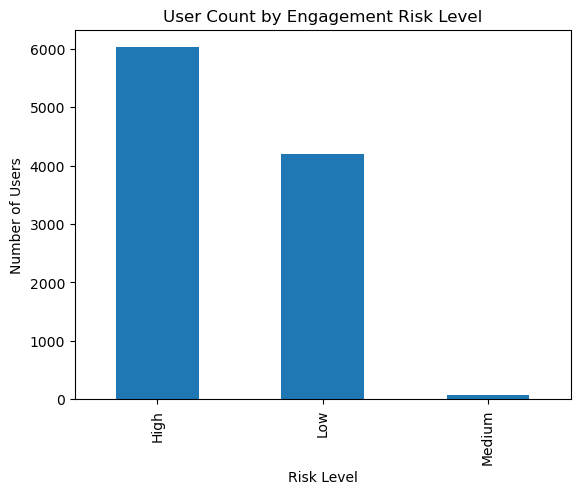

In [52]:
import matplotlib.pyplot as plt

master["risk_level"].value_counts().plot(kind="bar")
plt.title("User Count by Engagement Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
master["segment_name"].value_counts().plot(kind="bar")
plt.title("User Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

# Segment Chart

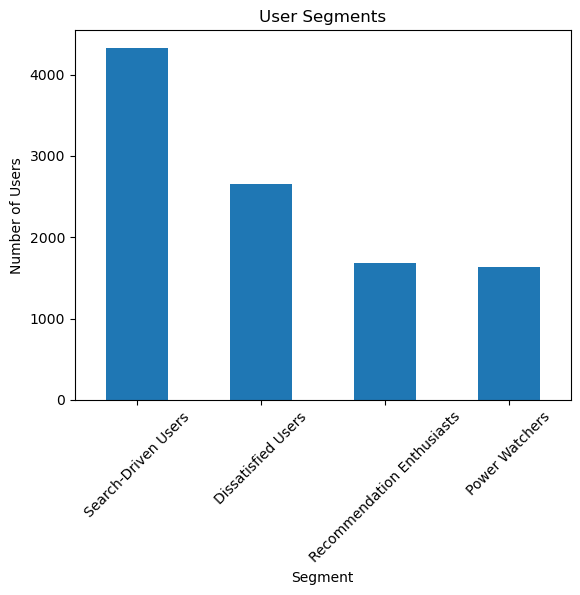

In [53]:
master["segment_name"].value_counts().plot(kind="bar")
plt.title("User Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

In [54]:
import shap

# Create transformed feature matrix

In [55]:
# Transform X_risk using the trained preprocessing pipeline
X_transformed = final_pipeline.named_steps["preprocessor"].transform(X_risk)

feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

# Create SHAP explainer

import shap

rf_model = final_pipeline.named_steps["model"]

X_transformed = final_pipeline.named_steps["preprocessor"].transform(X_risk)
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

# Use only 500 users for SHAP
sample = X_transformed_df.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(sample)

shap.plots.beeswarm(
    shap_values[:, :, 1],
    max_display=15
)